In [1]:
import math

class Value:
    def __init__(self,data,_children=(),_op='',label = ""):
        self.data = data
        self._prev = _children
        self._op = _op
        self.label = label
        self.grad =  0
        self._backward = lambda:None


    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out
    

    def __radd__(self, other):
        return self + other
        

    def __mul__(self,other):
        other = other if  isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad

        out._backward = _backward

        return out
    
    def __rmul__(self,other):
        return self * other
    
    def __sub__(self,other):
        return self + (-other)
    
    def __neg__(self):
        return self * -1
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __pow__(self, other):
        assert isinstance(other,(int,float)), "only supporting int/float powers for now "
        out = Value(self.data**other,(self,),f"**{other}")

        def _backward():
            self.grad = other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out

    def __iter__(self):
        for child in self._prev:
            yield  child

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t,(self,),'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad

        out._backward = _backward

        return out


    def backward(self):

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self,),"exp")
        def _backward():
            self.grad += out.data  * out.grad
        out._backward = _backward
        return out




In [2]:
v1 = Value(2);v1.label = "v1"
v2 = Value(3);v2.label = "v2"

In [3]:
v3 = v1+v2
v3._prev

(Value(data=2), Value(data=3))

In [4]:
def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges


from graphviz import Digraph

def draw_dots(root):
    nodes,edges = trace(root)
    dot = Digraph(name="graph",format='svg',graph_attr={"rankdir":"LR"})

    for n in nodes:
        uid = str(id(n))
        dot.node(uid,label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape='record')

        if n._op:
            dot.node(uid+n._op,label=n._op)
            dot.edge(uid+n._op,uid)

    for e1,e2 in edges:
        dot.edge(str(id(e1)),str(id(e2))+e2._op)

    return dot
    
    

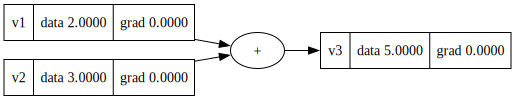

In [5]:
v3.label = "v3"
draw_dots(v3) 

In [6]:
a = Value(2.0,label='a')
b = Value(-3.0) ; b.label = 'b'
c = Value(10) ; c.label = "c"
e = a*b; e.label = "e"
d  = e + c ;d.label = "d"
f = Value(-2.0,label="f")
l = d * f ; l.label = "L"
m = l.tanh();m.label = "M"
l.backward()


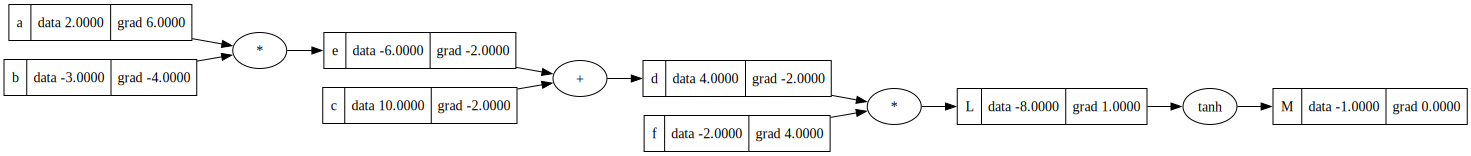

In [7]:
draw_dots(m)

In [8]:
l.grad = 1.0

In [9]:
# l._backward()
# d._backward()
# e._backward()

l = df

dl/dd = f * dl/dl

dd/dl = dd/dl * dl/dl

d = e +c 
dd/de = 1
dd/dl = dd/de * de/dl

In [10]:
import random
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for i in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self,x):
        act = sum(xi*wi for xi,wi in zip(x,self.w))+self.b
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [29]:
x = [1,2,3]
n = MLP(2,[4,4,1])
n(x)

Value(data=0.45141753078682706)

In [30]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

y_pred = [n(x) for x in xs]
y_pred

[Value(data=0.3696931395369675),
 Value(data=-0.06967519850835281),
 Value(data=0.41636708467046313),
 Value(data=0.37756129676408423)]

In [31]:
loss = sum((yp - yt)**2 for yp, yt in zip(y_pred, ys))
loss

Value(data=3.656316632441153)

In [32]:
loss.backward()
for p in n.parameters():
    p.data += -0.001 * p.grad

y_pred = [n(x) for x in xs]
loss = sum([(ygt - yout)**2  for ygt,yout in zip(y_pred,ys)])
loss


Value(data=3.6528638623836756)

In [33]:
loss.backward()
print("before:", n.parameters()[0].data)

for p in n.parameters():
    p.data += -0.05 * p.grad

print("after :", n.parameters()[0].data)
loss

before: 0.38112660629354
after : 0.38150119110669833


Value(data=3.6528638623836756)

In [34]:
m.grad = 1.0
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yp-ya)**2 for ya,yp in zip(ys,ypred))

    #zero_grad()
    for p in n.parameters():
        p.grad = 0.0
    #backward pass
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k,loss.data)

0 3.3063415136352363
1 3.2255101864317317
2 3.106895867355541
3 2.980632306415986
4 2.855133919402951
5 2.7305221246428486
6 2.6047814434508334
7 2.4761101886265893
8 2.3443597389366646
9 2.212095744052154
10 2.084666144830629
11 1.9684482626644717
12 1.867954966222837
13 1.7842057631981707
14 1.7155012657007749
15 1.6591218255291778
16 1.6124310650352447
17 1.573249290672977
18 1.5398802882564082
19 1.5110355125773134


In [36]:
answers = []
for ans in y_pred:
    if ans.data > 0.50:
        print(1)
        answers.append(ans)
    else:
        answers.append(ans)
        print(-1)

-1
-1
-1
-1


In [18]:
ys

[1.0, -1.0, -1.0, 1.0]